# 

In [7]:
import fastdfe as fd

In [8]:
vcf='allacma_fusca.hard_filtered.sorted.vcf.gz'
fasta='GCA_947179485.1.simple_header.earlGrey_masked.fasta'
a_gff='allacma_fusca.longest_isoform.autosome.gff3'
x_gff='allacma_fusca.longest_isoform.x.gff3'

In [24]:
a_p = fd.Parser(
    n=8,
    vcf=vcf,
    fasta=fasta,
    gff=a_gff,
    annotations=[
        fd.DegeneracyAnnotation(),
    ],
    stratifications=[fd.DegeneracyStratification()],
    skip_non_polarized=False
)

# Maybe the maximum parsimony ancestral annotation is a bad idea and should just include all sites. Then the spectra is already folded

In [25]:
a_spectra: fd.Spectra = a_p.parse()

INFO:Parser: Using stratification: [neutral, selected].
INFO:Parser: Loading VCF file
INFO:Parser: Loading GFF file
INFO:Parser: Loading FASTA file


INFO:PolyAllelicFiltration: Filtered out 28686 sites.
INFO:DegeneracyStratification: Number of sites with valid type: 144119
INFO:DegeneracyAnnotation: Annotated 209019 sites.
INFO:Parser: Included 144119 out of 3544506 sites in total from the VCF file.


<Axes: xlabel='frequency'>

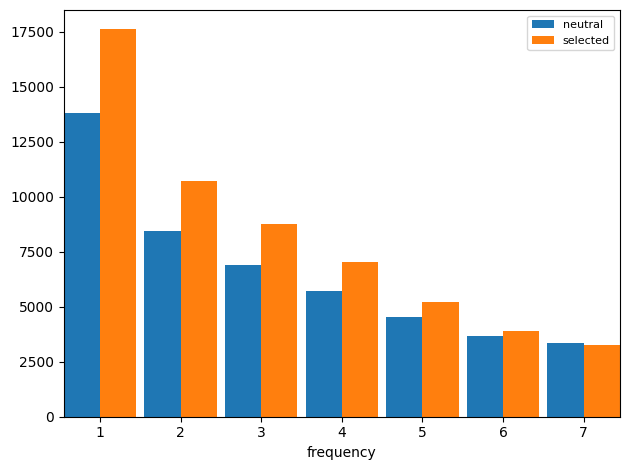

In [43]:
a_spectra.plot()

<Axes: xlabel='frequency'>

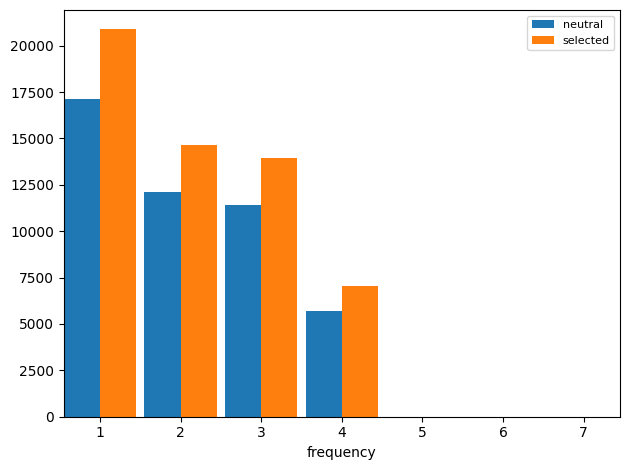

In [17]:
a_spectra.fold().plot()

In [ ]:
a_spectra.to_file("out/a_spectra_unfolded.csv")
a_spectra.fold().to_file("out/a_spectra_unfolded.csv")

In [ ]:
# This simple script with different gffs could be used to resample for alpha? 
# Need to figure out how to do that properly

In [19]:
# folded inference given maximum parsimony ancestral annotation
# Monomorphic site count information
a_sfs_neut: fd.Spectrum = a_spectra["neutral"]
a_sfs_sel: fd.Spectrum = a_spectra["selected"]
a_inf = fd.BaseInference(
    sfs_neut=a_sfs_neut.fold(),
    sfs_sel=a_sfs_sel.fold(),
    fixed_params=dict(all=dict(eps=0, S_b=1, p_b=0)),
    #do_bootstrap=True
)

In [23]:
a_sfs_neut

In [ ]:
a_inf.run()

In [ ]:
a_inf.plot_discretized()

In [40]:
# Give tool dfe_alpha SFS and bootstrap here
a_sfs_neut = fd.Spectra([5746147,3248,1328,903,730,501,535,592,632,446,472,465,526,0,0,0,0,0,0,0,0,0,0,0,0])
a_sfs_sel = fd.Spectra([4214009,3976,2070,1473,1277,944,1087,988,1117,869,891,928,677,0,0,0,0,0,0,0,0,0,0,0,0])
a_inf = fd.BaseInference(
    sfs_neut=a_sfs_neut.fold(),
    sfs_sel=a_sfs_sel.fold(),
    fixed_params=dict(all=dict(eps=0, S_b=1, p_b=0)),
    #do_bootstrap=True
)

In [41]:
a_inf.run()

INFO:Discretization: Precomputing linear DFE-SFS transformation using midpoint integration.


INFO:BaseInference: Successfully finished optimization after 1 iterations and 6 function evaluations, obtaining a log-likelihood of -4039.1073691718484.
INFO:BaseInference: Inferred parameters: {all.S_d: -0.01, all.b: 10.0, all.p_b: 0.0, all.S_b: 1.0, all.eps: 0.0}.


<Axes: title={'center': 'discretized DFE'}, xlabel='S', ylabel='fraction'>

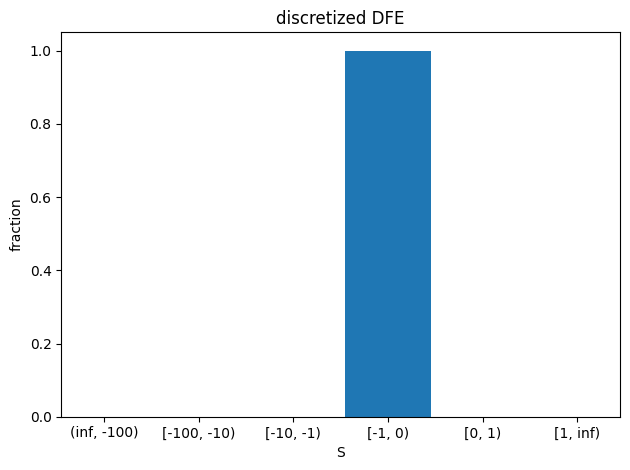

In [42]:
a_inf.plot_discretized()

In [33]:
fd.Spectra([5746147,3248,1328,903,730,501,535,592,632,446,472,465,526,0,0,0,0,0,0,0,0,0,0,0,0])

In [44]:
(7500*200)/(463000000)

0.0032397408207343412

In [45]:
0.05/(4*5e-09)

2500000.0